# Analisis Clustering Ukuran Benih Lele
Notebook ini memuat ringkasan cluster, evaluasi kualitas clustering, dan interpretasi hasil berdasarkan seluruh bounding box anotasi ground truth pada dataset `train`, `valid`, dan `test`.


In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from project_helpers import (
    DATASET_ANALYSIS_DIR,
    EVALUATION_DIR,
    MODEL_ARTIFACTS_DIR,
    build_cluster_interpretation,
    build_cluster_summary,
    build_feature_matrix,
    build_size_mapping,
    evaluate_clustering,
)

CLASSIFIED_PATH = DATASET_ANALYSIS_DIR / "classified_sizes_all_dataset.csv"
SCALER_PATH = MODEL_ARTIFACTS_DIR / "scaler_kmeans.pkl"
KMEANS_PATH = MODEL_ARTIFACTS_DIR / "kmeans_size.pkl"

for path in [CLASSIFIED_PATH, SCALER_PATH, KMEANS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Artefak tidak ditemukan: {path}")

df = pd.read_csv(CLASSIFIED_PATH)
feature_df, X = build_feature_matrix(df)
scaler = joblib.load(SCALER_PATH)
kmeans = joblib.load(KMEANS_PATH)
X_scaled = scaler.transform(X)
df["cluster"] = kmeans.predict(X_scaled)

legacy_size_column = "size_" + "class"

if "size_group" not in df.columns:
    mapping_source = feature_df.copy()
    mapping_source["cluster"] = df["cluster"]
    mapping_source["area_px"] = feature_df["area_px"]
    mapping = build_size_mapping(mapping_source)
    df["size_group"] = df["cluster"].map(mapping)
if legacy_size_column in df.columns:
    df = df.drop(columns=[legacy_size_column])

print(f"Classified dataset file: {CLASSIFIED_PATH}")
print(f"Evaluation folder: {EVALUATION_DIR}")
print(f"Jumlah deteksi: {len(df)}")
print(f"ID cluster K-Means unik: {sorted(df['cluster'].unique())}")
if "source_split" in df.columns:
    display(
        df.groupby("source_split")
        .size()
        .rename("detection_count")
        .reset_index()
    )
display(df.head())


Classified dataset file: E:\Project\artifacts\dataset_analysis\classified_sizes_all_dataset.csv
Evaluation folder: E:\Project\artifacts\evaluation
Jumlah deteksi: 2431
ID cluster K-Means unik: [np.int32(0), np.int32(1), np.int32(2)]


,source_split,detection_count
0,test,249
1,train,2081
2,valid,101


,source_split,filename,filepath,label_path,annotation_index,class_id,box_source,x1,y1,x2,y2,width_px,height_px,cluster,area_px,size_group
0,train,184_jpg.rf.e084c2d1d6e4f0e63f9fa697b0f39c9a.jpg,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,0,0,ground_truth_label,120.030,174.565,1065.630,444.875,945.60,270.31,2,255605.1360,Kelompok 2
1,train,184_jpg.rf.e084c2d1d6e4f0e63f9fa697b0f39c9a.jpg,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,1,0,ground_truth_label,440.035,196.570,1287.805,658.370,847.77,461.80,0,391500.1860,Kelompok 3
2,train,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,0,0,ground_truth_label,152.030,140.570,1104.870,717.990,952.84,577.42,0,550188.8728,Kelompok 3
3,train,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,1,0,ground_truth_label,130.035,62.570,804.205,629.030,674.17,566.46,0,381890.3382,Kelompok 3
4,train,185_jpg.rf.28fec1139bc2217615fc0c26f8b9055b.jpg,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,C:\Users\Alwan Fauzi\Documents\GitHub\finalfix...,2,0,ground_truth_label,28.035,156.570,724.225,649.790,696.19,493.22,0,343374.8318,Kelompok 3


In [2]:
cluster_summary = build_cluster_summary(df)
interpretation_lines = build_cluster_interpretation(cluster_summary)

display(cluster_summary)
print("Interpretasi hasil clustering:")
for line in interpretation_lines:
    print("-", line)


,cluster,size_group,sample_count,mean_width_px,mean_height_px,mean_area_px,median_area_px,min_area_px,max_area_px,mean_diag_px,mean_aspect_ratio,share
0,1,Kelompok 1,727,421.260083,513.157744,207261.794889,212855.90520,47077.0030,339680.4200,685.589761,0.948475,0.299054
1,2,Kelompok 2,464,904.368060,338.593060,306572.829617,308308.22795,145109.6504,509091.8694,968.148171,2.779434,0.190868
2,0,Kelompok 3,1240,613.284048,759.618589,438270.977920,428439.05470,238269.5367,841640.8518,1007.838636,0.908431,0.510078


Interpretasi hasil clustering:
- Urutan ukuran berdasarkan rata-rata area adalah Kelompok 1 < Kelompok 2 < Kelompok 3.
- Kelompok 1 mencakup 727 objek (29.9%) dengan rata-rata area 207,262 px2, median 212,856 px2, rentang 47,077-339,680 px2, dan bounding box relatif seimbang antara lebar dan tinggi.
- Kelompok 2 mencakup 464 objek (19.1%) dengan rata-rata area 306,573 px2, median 308,308 px2, rentang 145,110-509,092 px2, dan bounding box cenderung lebih melebar secara horizontal.
- Kelompok 3 mencakup 1240 objek (51.0%) dengan rata-rata area 438,271 px2, median 428,439 px2, rentang 238,270-841,641 px2, dan bounding box relatif seimbang antara lebar dan tinggi.


In [3]:
clustering_metrics = evaluate_clustering(X_scaled, df["cluster"].to_numpy())
display(clustering_metrics)

metric_row = clustering_metrics.iloc[0]
silhouette = metric_row["silhouette_score"]
db_index = metric_row["davies_bouldin_score"]
ch_index = metric_row["calinski_harabasz_score"]

if silhouette >= 0.5:
    silhouette_note = "pemisahan antarkelompok kuat"
elif silhouette >= 0.25:
    silhouette_note = "pemisahan cluster cukup baik"
else:
    silhouette_note = "pemisahan cluster masih lemah"

print(f"Silhouette score = {silhouette:.3f}, artinya {silhouette_note}.")
print(f"Davies-Bouldin score = {db_index:.3f}; semakin kecil nilainya semakin baik.")
print(f"Calinski-Harabasz score = {ch_index:.1f}; semakin besar nilainya semakin baik.")


,n_samples,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,largest_cluster_share,smallest_cluster_share
0,2431,3,0.42394,0.795584,2031.342689,0.510078,0.190868


Silhouette score = 0.424, artinya pemisahan cluster cukup baik.
Davies-Bouldin score = 0.796; semakin kecil nilainya semakin baik.
Calinski-Harabasz score = 2031.3; semakin besar nilainya semakin baik.


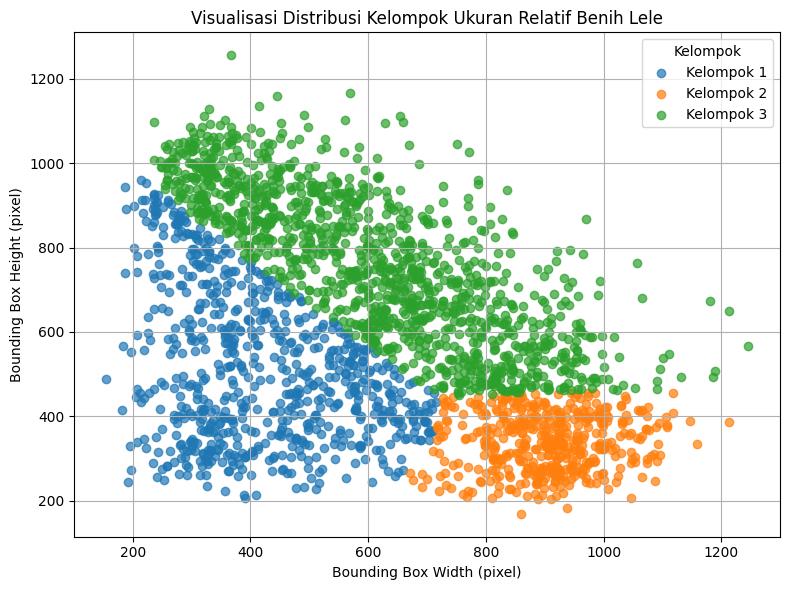

In [4]:
plt.figure(figsize=(8, 6))
for row in cluster_summary.itertuples(index=False):
    subset = df[df["cluster"] == row.cluster]
    plt.scatter(
        subset["width_px"],
        subset["height_px"],
        alpha=0.7,
        label=row.size_group,
    )

plt.xlabel("Bounding Box Width (pixel)")
plt.ylabel("Bounding Box Height (pixel)")
plt.title("Visualisasi Distribusi Kelompok Ukuran Relatif Benih Lele")
plt.legend(title="Kelompok")
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

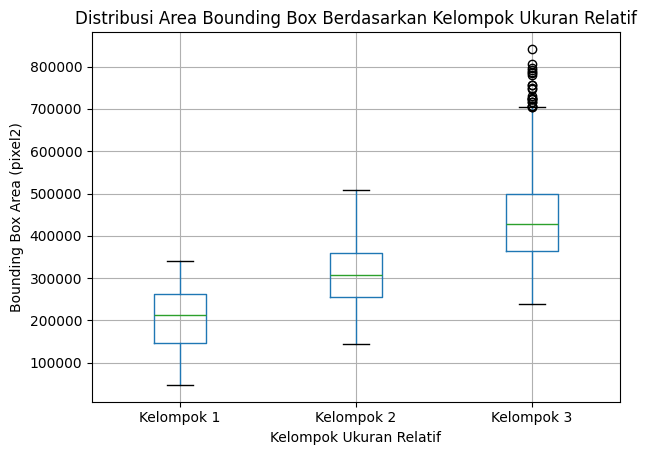

In [5]:
plot_order = cluster_summary["size_group"].tolist()
df_plot = df.copy()
df_plot["size_group"] = pd.Categorical(df_plot["size_group"], categories=plot_order, ordered=True)

plt.figure(figsize=(8, 6))
df_plot.boxplot(column="area_px", by="size_group", grid=True)
plt.xlabel("Kelompok Ukuran Relatif")
plt.ylabel("Bounding Box Area (pixel2)")
plt.title("Distribusi Area Bounding Box Berdasarkan Kelompok Ukuran Relatif")
plt.suptitle("")
plt.tight_layout()
plt.show()


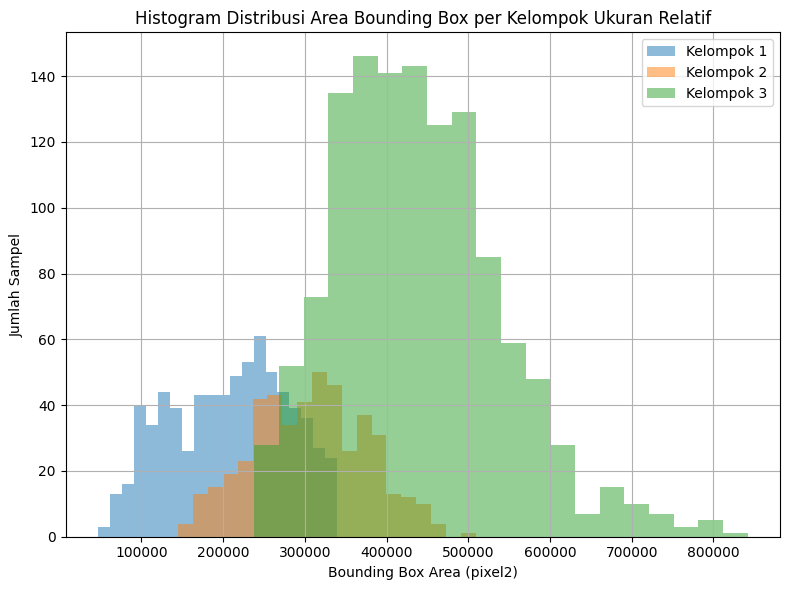

In [6]:
plt.figure(figsize=(8, 6))

for row in cluster_summary.itertuples(index=False):
    subset = df[df["cluster"] == row.cluster]
    label = row.size_group
    plt.hist(
        subset["area_px"],
        bins=20,
        alpha=0.5,
        label=label,
    )

plt.xlabel("Bounding Box Area (pixel2)")
plt.ylabel("Jumlah Sampel")
plt.title("Histogram Distribusi Area Bounding Box per Kelompok Ukuran Relatif")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
